In [25]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
import seaborn as sns


In [3]:
df = pd.read_excel('../data/processed/processed_first_task.xlsx')
df.head()

,Unnamed: 0,symptoms,Angina range,depression,ECG range,WMSI stress,D WMSI,WMSI range,target,log_WMSI_stress,WMSI_stress_high
0,0,3,0,3,0,1.000,0.000,0,1.0,0.000000,0
1,1,3,0,3,0,1.125,0.000,0,1.0,0.117783,1
2,2,3,0,3,0,1.125,0.125,1,0.0,0.117783,1
3,3,1,1,3,0,1.000,-0.190,1,1.0,0.000000,0
4,4,3,0,3,0,1.120,0.120,1,0.0,0.113329,0


In [43]:
df = df.drop(columns = 'Unnamed: 0')

In [18]:
def sigma(z):
    return 1/(1+np.exp(-z))

def grad(y, X, theta):
    n = y.shape[0]
    return 1/n * X.transpose() @ (sigma(X @ theta) - y)

def L(y, X, theta):
    n = y.shape[0]
    return -1/(n)*np.sum(y*np.log(sigma(X @ theta)) + (1 - y)*np.log(1 - sigma(X @ theta)))

def fit(y_train, X_train, y_test, X_test, theta_0, alpha=0.001, nsteps=100):
    theta = np.copy(theta_0)
    train_loss = [L(y_train, X_train, theta)]
    test_loss = [L(y_test, X_test, theta)]
    for i in range(nsteps):
        theta -= alpha * grad(y_train, X_train, theta)
        train_loss.append(L(y_train, X_train, theta))
        test_loss.append(L(y_test, X_test, theta))
    return train_loss, test_loss, theta

In [10]:
df = df.dropna()

In [ ]:
X = df[['Angina range', 'ECG range', 'WMSI range']]
y = df['target']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, random_state=42, stratify=y
)

mean_train = X_train.mean()
std_train = X_train.std()

X_train_scaled = (X_train - mean_train) / std_train
X_test_scaled = (X_test - mean_train) / std_train  

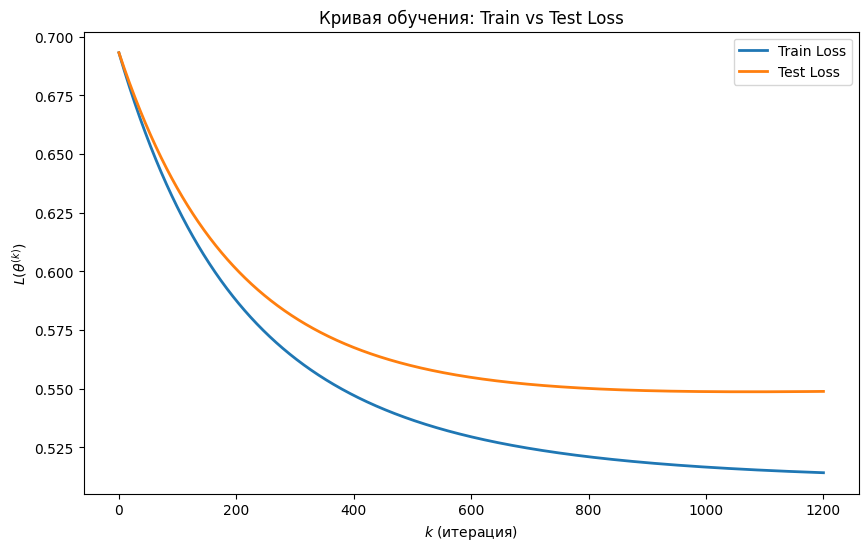

In [ ]:
n_train = len(X_train_scaled)
n_test = len(X_test_scaled)
X_train_with_intercept = np.hstack((np.ones((n_train, 1)), X_train_scaled))
X_test_with_intercept = np.hstack((np.ones((n_test, 1)), X_test_scaled))

m = 3 
theta_0 = np.zeros(m + 1)  

train_loss_history, test_loss_history, theta_star = fit(
    y_train, X_train_with_intercept, 
    y_test, X_test_with_intercept, 
    theta_0, alpha=1e-2, nsteps=1200
)

# Кривая обучения на трейне и тесте
plt.figure(figsize=(10, 6))
plt.plot(train_loss_history, label='Train Loss', linewidth=2)
plt.plot(test_loss_history, label='Test Loss', linewidth=2)
plt.xlabel('$k$ (итерация)')
plt.ylabel('$L(\\theta^{(k)})$')
plt.title('Кривая обучения: Train vs Test Loss')
plt.legend()

In [24]:
print(f"Финальный train loss: {train_loss_history[-1]:.4f}")
print(f"Финальный test loss: {test_loss_history[-1]:.4f}")

Финальный train loss: 0.5142
Финальный test loss: 0.5489



МЕТРИКИ НА ТЕСТОВЫХ ДАННЫХ
Accuracy:  0.7460
ROC-AUC:   0.6719
F1-score:  0.3846

CLASSIFICATION REPORT
              precision    recall  f1-score   support

    No Event       0.79      0.90      0.84        93
       Event       0.53      0.30      0.38        33

    accuracy                           0.75       126
   macro avg       0.66      0.60      0.61       126
weighted avg       0.72      0.75      0.72       126



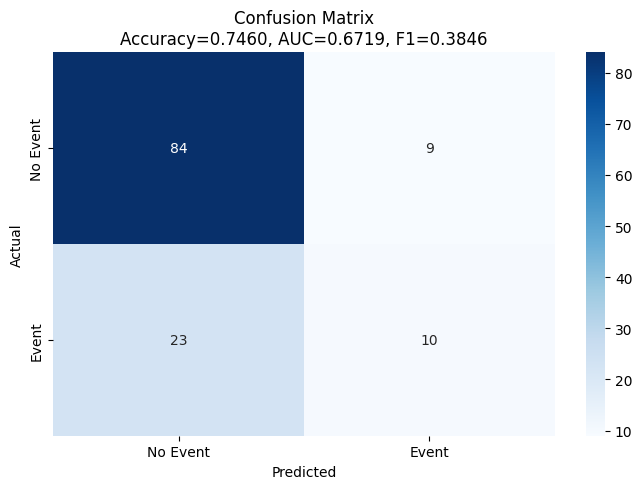

In [30]:
from sklearn.metrics import accuracy_score, roc_auc_score, f1_score, confusion_matrix, classification_report

def predict_proba(X, theta):
    return sigma(X @ theta)

def predict(X, theta, threshold=0.5):
    return (predict_proba(X, theta) >= threshold).astype(int)

y_pred_proba = predict_proba(X_test_with_intercept, theta_star)
y_pred = predict(X_test_with_intercept, theta_star)

accuracy = accuracy_score(y_test, y_pred)
auc = roc_auc_score(y_test, y_pred_proba)
f1 = f1_score(y_test, y_pred)

print("\n" + "="*60)
print("МЕТРИКИ НА ТЕСТОВЫХ ДАННЫХ")
print("="*60)
print(f"Accuracy:  {accuracy:.4f}")
print(f"ROC-AUC:   {auc:.4f}")
print(f"F1-score:  {f1:.4f}")

# Classification Report
print("\n" + "="*60)
print("CLASSIFICATION REPORT")
print("="*60)
print(classification_report(y_test, y_pred, target_names=['No Event', 'Event']))

# Confusion Matrix
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(7, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=['No Event', 'Event'],
            yticklabels=['No Event', 'Event'])
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title(f'Confusion Matrix\nAccuracy={accuracy:.4f}, AUC={auc:.4f}, F1={f1:.4f}')
plt.tight_layout()
plt.show()


In [31]:
theta_star

array([-0.99337805,  0.69032121,  0.03080407,  0.0171286 ])


МЕТРИКИ НА ТЕСТОВЫХ ДАННЫХ
Accuracy:  0.7460
ROC-AUC:   0.6442
F1-score:  0.2381

CLASSIFICATION REPORT
              precision    recall  f1-score   support

    No Event       0.76      0.96      0.85        93
       Event       0.56      0.15      0.24        33

    accuracy                           0.75       126
   macro avg       0.66      0.55      0.54       126
weighted avg       0.71      0.75      0.69       126



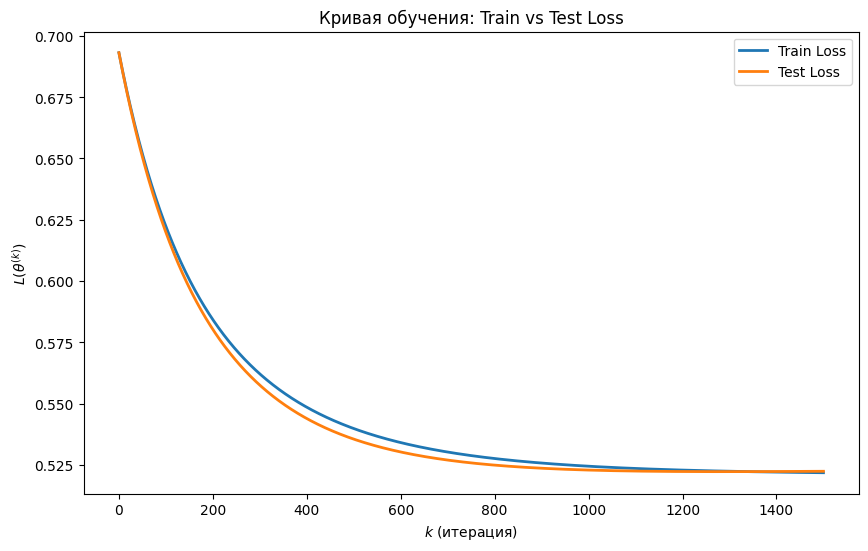

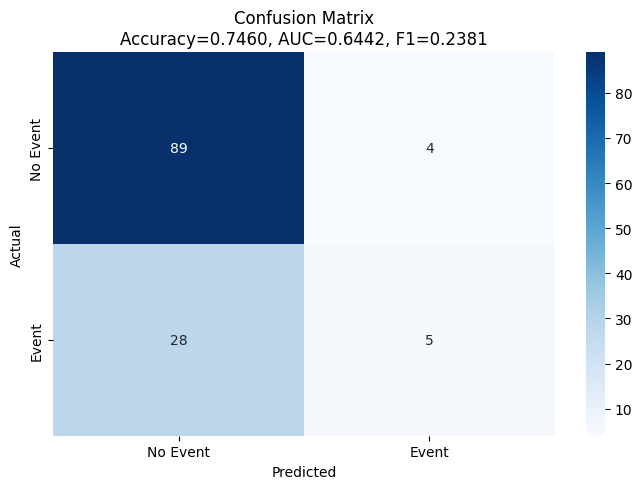

In [35]:
X = df[['symptoms', 'depression', 'log_WMSI_stress', 'D WMSI']]
y = df['target']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, random_state=42, stratify=y
)

mean_train = X_train.mean()
std_train = X_train.std()

X_train_scaled = (X_train - mean_train) / std_train
X_test_scaled = (X_test - mean_train) / std_train 

n_train = len(X_train_scaled)
n_test = len(X_test_scaled)
X_train_with_intercept = np.hstack((np.ones((n_train, 1)), X_train_scaled))
X_test_with_intercept = np.hstack((np.ones((n_test, 1)), X_test_scaled))

m = len(X.columns.tolist())
theta_0 = np.zeros(m + 1)  

train_loss_history, test_loss_history, theta_star = fit(
    y_train, X_train_with_intercept, 
    y_test, X_test_with_intercept, 
    theta_0, alpha=1e-2, nsteps=1500
)

# Кривая обучения на трейне и тесте
plt.figure(figsize=(10, 6))
plt.plot(train_loss_history, label='Train Loss', linewidth=2)
plt.plot(test_loss_history, label='Test Loss', linewidth=2)
plt.xlabel('$k$ (итерация)')
plt.ylabel('$L(\\theta^{(k)})$')
plt.title('Кривая обучения: Train vs Test Loss')
plt.legend()


def predict_proba(X, theta):
    return sigma(X @ theta)

def predict(X, theta, threshold=0.5):
    return (predict_proba(X, theta) >= threshold).astype(int)

y_pred_proba = predict_proba(X_test_with_intercept, theta_star)
y_pred = predict(X_test_with_intercept, theta_star)

accuracy = accuracy_score(y_test, y_pred)
auc = roc_auc_score(y_test, y_pred_proba)
f1 = f1_score(y_test, y_pred)

print("\n" + "="*60)
print("МЕТРИКИ НА ТЕСТОВЫХ ДАННЫХ")
print("="*60)
print(f"Accuracy:  {accuracy:.4f}")
print(f"ROC-AUC:   {auc:.4f}")
print(f"F1-score:  {f1:.4f}")

# Classification Report
print("\n" + "="*60)
print("CLASSIFICATION REPORT")
print("="*60)
print(classification_report(y_test, y_pred, target_names=['No Event', 'Event']))

# Confusion Matrix
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(7, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=['No Event', 'Event'],
            yticklabels=['No Event', 'Event'])
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title(f'Confusion Matrix\nAccuracy={accuracy:.4f}, AUC={auc:.4f}, F1={f1:.4f}')
plt.tight_layout()
plt.show()


In [79]:
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split, GridSearchCV, StratifiedKFold, cross_val_score, cross_validate
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, recall_score,RocCurveDisplay, roc_auc_score, make_scorer, precision_recall_curve, precision_score, f1_score, ConfusionMatrixDisplay

from sklearn.pipeline import Pipeline

# features_2d = ['symptoms', 'depression', 'log_WMSI_stress', 'D WMSI']
features_2d = ['WMSI range', 'symptoms', 'depression']

X_small = df[features_2d].copy()
y_work = y.copy()

model_log = Pipeline([
    ('scaler', StandardScaler()),
    ('clf', LogisticRegression(class_weight='balanced', random_state=42))
])

cv = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

scores = cross_val_score(
    model_log,
    X_small,
    y_work,
    scoring=make_scorer(f1_score),
    cv=cv,
    n_jobs=-1
)

print(f"F1 CV mean: {scores.mean():.4f}")
print(f"F1 CV std : {scores.std():.4f}")

model_log.fit(X_small, y_work)

coef = model_log.named_steps["clf"].coef_.ravel()

coef_df = (
    pd.Series(coef, index=features_2d)
    .sort_values(key=np.abs, ascending=False)
)

coef_df

F1 CV mean: 0.5312
F1 CV std : 0.0598


WMSI range    0.712673
depression   -0.081975
symptoms     -0.071802
dtype: float64

In [78]:
from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
import pandas as pd

features_2d = ['Angina range', 'ECG range', 'WMSI range', 'symptoms', 'depression']

X_small = df[features_2d].copy()
y_work = y.copy()

model_log = Pipeline([
    ('scaler', StandardScaler()),
    ('clf', LogisticRegression(class_weight='balanced', penalty='l1',
    C=0.1,  # сила регуляризации (меньше = сильнее)
    solver='saga',
    max_iter=1000,
    random_state=42))
])

model_log.fit(X_small, y_work)

# ПРАВИЛЬНО: берем coef_ у последнего шага (clf)
l1_importance = pd.DataFrame({
    'feature': features_2d,
    'coefficient': model_log.named_steps['clf'].coef_[0],  # <--- исправлено
    'selected': model_log.named_steps['clf'].coef_[0] != 0   # <--- исправлено
}).sort_values('coefficient', ascending=False)

print(l1_importance)
print(f"\nОтобрано признаков: {l1_importance['selected'].sum()}")

        feature  coefficient  selected
2    WMSI range     0.657936      True
0  Angina range     0.000000     False
1     ECG range     0.000000     False
4    depression    -0.019201      True
3      symptoms    -0.020856      True

Отобрано признаков: 3


In [80]:
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

oof_proba = np.zeros(len(y_work))

for train_idx, val_idx in cv.split(X_small, y_work):

    X_tr, X_val = X_small.iloc[train_idx], X_small.iloc[val_idx]
    y_tr, y_val = y_work.iloc[train_idx], y_work.iloc[val_idx]

    model_log.fit(X_tr, y_tr)

    proba = model_log.predict_proba(X_val)[:, 1]
    oof_proba[val_idx] = proba

thresholds = np.linspace(0, 1, 1000)
f1_scores = []

for t in thresholds:
    preds = (oof_proba >= t).astype(int)
    f1_scores.append(f1_score(y_work, preds))

best_idx = np.argmax(f1_scores)
best_threshold = thresholds[best_idx]

print("Best threshold:", best_threshold)
print("Best F1:", f1_scores[best_idx])

Best threshold: 0.4824824824824825
Best F1: 0.5346534653465347


In [81]:

# Функция для расчета специфичности
def specificity_score(y_true, y_pred):
    """
    Рассчитывает специфичность (True Negative Rate)
    Specificity = TN / (TN + FP)
    """
    tn, fp, fn, tp = confusion_matrix(y_true, y_pred).ravel()
    specificity = tn / (tn + fp) if (tn + fp) > 0 else 0
    return specificity

# Создаем scorer для специфичности
specificity_scorer = make_scorer(specificity_score)

scoring = {
    "f1": make_scorer(f1_score),
    "precision": make_scorer(precision_score),
    "recall": make_scorer(recall_score),
    "accuracy": make_scorer(accuracy_score),
    "specificity": specificity_scorer, 
    'auc-roc' : make_scorer(roc_auc_score)
}

cv_results = cross_validate(
    model_log,
    X_small,
    y_work,
    scoring=scoring,
    cv=cv,
    n_jobs=-1
)

metrics_df = pd.DataFrame({
    "F1 mean": [cv_results["test_f1"].mean()],
    "F1 std": [cv_results["test_f1"].std()],
    "Precision mean": [cv_results["test_precision"].mean()],
    "Precision std": [cv_results["test_precision"].std()],
    "Recall mean": [cv_results["test_recall"].mean()],
    "Recall std": [cv_results["test_recall"].std()],
    "Specificity mean": [cv_results["test_specificity"].mean()],  # Добавляем среднее specificity
    "Specificity std": [cv_results["test_specificity"].std()],    # Добавляем std specificity
    "Accuracy mean": [cv_results["test_accuracy"].mean()],
    "Accuracy std": [cv_results["test_accuracy"].std()],
    "AUC mean": [cv_results["test_accuracy"].mean()],
    "AUC std": [cv_results["test_accuracy"].std()],
})

metrics_df

,F1 mean,F1 std,Precision mean,Precision std,Recall mean,Recall std,Specificity mean,Specificity std,Accuracy mean,Accuracy std,AUC mean,AUC std
0,0.531205,0.059846,0.475406,0.042891,0.607407,0.100342,0.758719,0.034222,0.71903,0.02798,0.71903,0.02798


In [53]:
metrics_df

,F1 mean,F1 std,Precision mean,Precision std,Recall mean,Recall std,Specificity mean,Specificity std,Accuracy mean,Accuracy std,AUC mean,AUC std
0,0.522275,0.055765,0.450027,0.044249,0.623362,0.078627,0.726361,0.020728,0.699168,0.029487,0.699168,0.029487


In [ ]:
"""
Angina range
ECG range
WMSI range

"""
metrics_df 


,F1 mean,F1 std,Precision mean,Precision std,Recall mean,Recall std,Specificity mean,Specificity std,Accuracy mean,Accuracy std,AUC mean,AUC std
0,0.531205,0.059846,0.475406,0.042891,0.607407,0.100342,0.758719,0.034222,0.71903,0.02798,0.71903,0.02798
